## 1. Isolating the Causal Effect of Age on Women's Health Agency

Loading and preparing data...
------------------------------
DATA AUDIT REPORT
------------------------------
Initial row count: 512408
Final row count after dropping NaNs: 15437
Rows lost: 496971 (96.99%)

CHECKING TREATMENT BALANCE (Wealth Index Distribution):
wealth_index
1    0.239878
2    0.251020
3    0.221546
4    0.166094
5    0.121461

Initializing DoWhy Model and Identifying Effect...

Estimating Causal Effects (Theory Competition)...

THEORY COMPETITION: AGE vs. HOUSEHOLD SENIORITY
Total Effect of Age:  0.00221 (p=0.9483)
Direct Effect of Age: 0.00100 (p=0.0054)

Running Refutation Stress Tests on the Total Effect...

[Refutation 1/3] Adding a Random Common Cause...
Refute: Add a random common cause
Estimated effect:0.0022139678915095162
New effect:0.0022144825159835955
p value:0.3560074453381155


[Refutation 2/3] Replacing Age with a Placebo Treatment...
Refute: Use a Placebo Treatment
Estimated effect:0.0022139678915095162
New effect:0.0003635618352472392
p value:0.159280

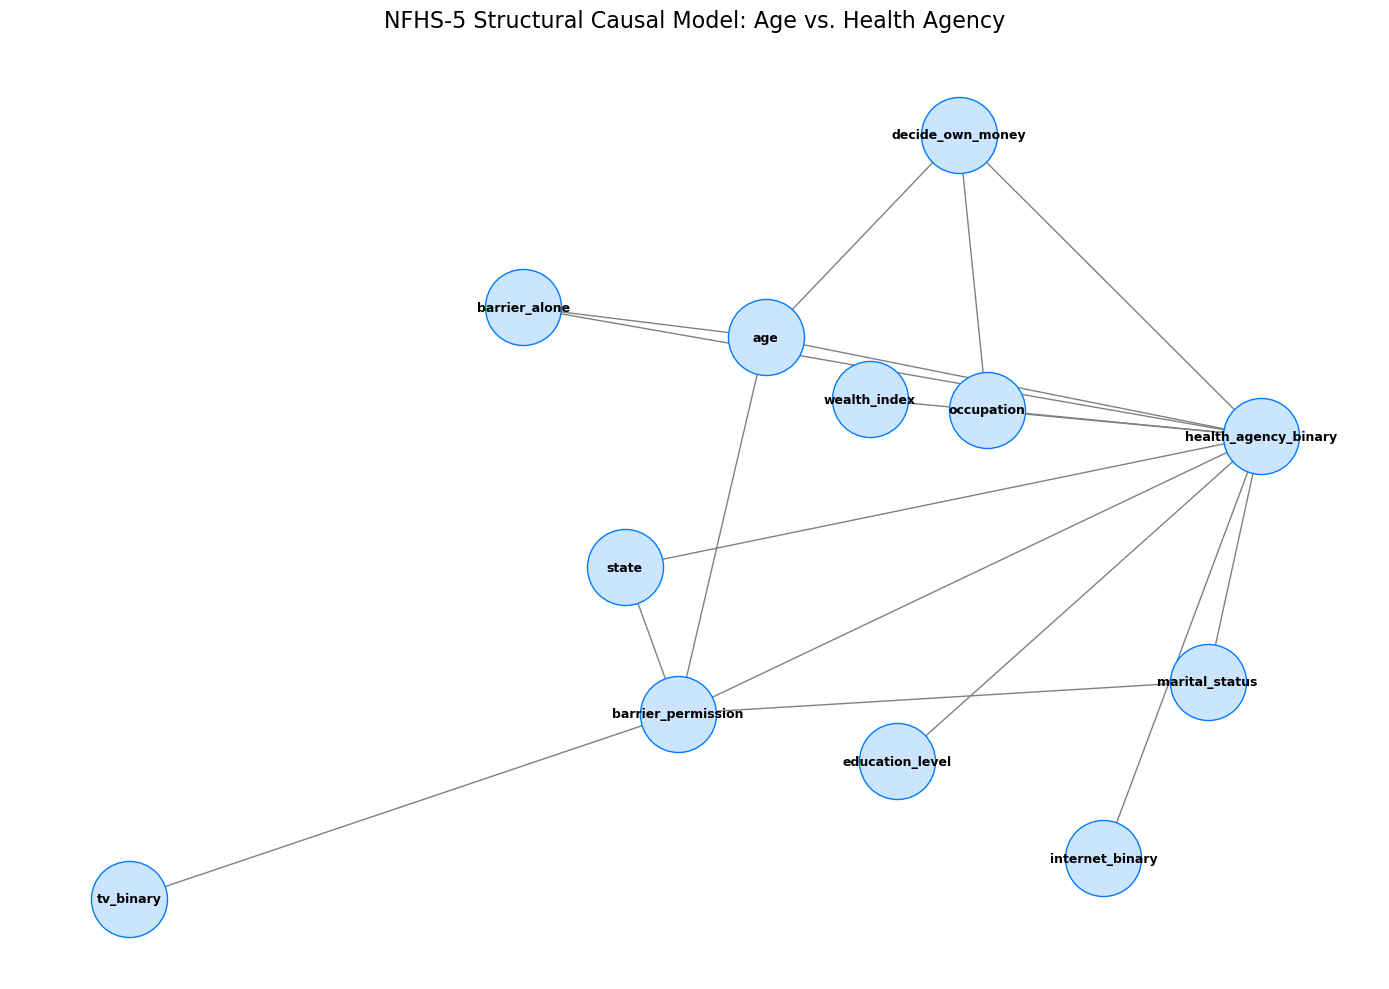

In [24]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import warnings
import logging

# Suppress standard Python and Pandas warnings
warnings.filterwarnings('ignore')

# Silence DoWhy's verbose logging (only show critical errors)
logging.getLogger('dowhy').setLevel(logging.ERROR)

# ==========================================
# 1. DATA PREPARATION & CATEGORICAL ENCODING (SCRIPT 1)
# ==========================================
print("Loading and preparing data...")
df = pd.read_csv('india_nfhs5_cleaned.csv')

# Restrict to patrilocal households (Married or Living with partner)
df = df[df['marital_status'].isin([1, 2])]

# Keep only necessary nodes. Insurance columns are explicitly excluded.
columns_to_keep = [
    'age', 'decide_health', 'barrier_permission', 'barrier_alone', 'decide_own_money',
    'state', 'marital_status', 'education_level', 'wealth_index', 'occupation',
    'internet_use', 'freq_tv'
]
initial_count = len(df)
df = df.dropna(subset=columns_to_keep).copy()
final_count = len(df)

# Binarize the Outcome (1 = Agency, 0 = No Agency)
df['health_agency_binary'] = np.where(df['decide_health'].isin([1, 2, 3]), 1, 0)

df['internet_binary'] = np.where(df['internet_use'] > 0, 1, 0)
df['tv_binary'] = np.where(df['freq_tv'] > 0, 1, 0)

# DATA BALANCE & AUDIT PRINT STATEMENTS
print("-" * 30)
print(f"DATA AUDIT REPORT")
print("-" * 30)
print(f"Initial row count: {initial_count}")
print(f"Final row count after dropping NaNs: {final_count}")
print(f"Rows lost: {initial_count - final_count} ({((initial_count - final_count)/initial_count)*100:.2f}%)")

print("\nCHECKING TREATMENT BALANCE (Wealth Index Distribution):")
print(df['wealth_index'].value_counts(normalize=True).sort_index().to_string())

# Cast variables to 'category' dtype so DoWhy and statsmodels automatically create dummies
categorical_cols = [
    'state', 'marital_status', 'occupation', 
    'barrier_permission', 'barrier_alone', 'decide_own_money'
]
for col in categorical_cols:
    df[col] = df[col].astype('category')


# ==========================================
# 2. STEP 1 & 2: MODEL AND IDENTIFY
# ==========================================
print("\nInitializing DoWhy Model and Identifying Effect...")

causal_graph = """
digraph {
    age -> health_agency_binary;

    age -> barrier_permission;
    age -> barrier_alone;
    age -> decide_own_money;
    
    barrier_permission -> health_agency_binary;
    barrier_alone -> health_agency_binary;
    decide_own_money -> health_agency_binary;

    state -> barrier_permission;
    state -> health_agency_binary;
    marital_status -> barrier_permission;
    marital_status -> health_agency_binary;

    education_level -> health_agency_binary;
    wealth_index -> health_agency_binary;
    
    occupation -> decide_own_money;
    occupation -> health_agency_binary;
    
    internet_binary -> health_agency_binary;
    tv_binary -> barrier_permission;
}
"""

model = CausalModel(
    data=df,
    treatment='age',
    outcome='health_agency_binary',
    graph=causal_graph
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)


# ==========================================
# 3. STEP 3: ESTIMATE (MECHANISM COMPETITION)
# ==========================================
print("\nEstimating Causal Effects (Theory Competition)...")

# DoWhy Native Estimator for Total Effect (to feed into Refuters later)
estimate_dowhy_total = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)

# Statsmodels implementation for the Direct Effect (Freezing the mediators)
formula_direct = (
    "health_agency_binary ~ age + barrier_permission + barrier_alone + decide_own_money + "
    "state + marital_status + education_level + wealth_index + occupation + "
    "internet_binary + tv_binary"
)
results_direct = smf.ols(formula_direct, data=df).fit()

# Safely extract DoWhy values (handling both arrays and floats)
total_coef = estimate_dowhy_total.value
total_coef = total_coef[0] if isinstance(total_coef, (np.ndarray, list)) else total_coef

total_pval_dict = estimate_dowhy_total.test_stat_significance()
total_pval = total_pval_dict['p_value']
total_pval = total_pval[0] if isinstance(total_pval, (np.ndarray, list, tuple)) else total_pval

# Extract Statsmodels values
direct_coef = results_direct.params['age']
direct_pval = results_direct.pvalues['age']

print("\n=======================================================")
print("THEORY COMPETITION: AGE vs. HOUSEHOLD SENIORITY")
print("=======================================================")
print(f"Total Effect of Age:  {total_coef:.5f} (p={total_pval:.4f})")
print(f"Direct Effect of Age: {direct_coef:.5f} (p={direct_pval:.4f})")
print("=======================================================\n")

# ==========================================
# 4. STEP 4: REFUTE (ROBUSTNESS CHECKS - OPTIMIZED)
# ==========================================
print("Running Refutation Stress Tests on the Total Effect...")

# Test 1: Random Common Cause
print("\n[Refutation 1/3] Adding a Random Common Cause...")
refute_rcc = model.refute_estimate(
    identified_estimand, 
    estimate_dowhy_total, 
    method_name="random_common_cause",
    num_simulations=5  # <-- Throttles the heavy lifting
)
print(refute_rcc)

# Test 2: Placebo Treatment
print("\n[Refutation 2/3] Replacing Age with a Placebo Treatment...")
refute_placebo = model.refute_estimate(
    identified_estimand, 
    estimate_dowhy_total, 
    method_name="placebo_treatment_refuter", 
    placebo_type="permute",
    num_simulations=5  # <-- Throttles the heavy lifting
)
print(refute_placebo)

# Test 3: Data Subset Refuter
print("\n[Refutation 3/3] Running on a random Data Subset (80%)...")
refute_subset = model.refute_estimate(
    identified_estimand, 
    estimate_dowhy_total, 
    method_name="data_subset_refuter", 
    subset_fraction=0.8,
    num_simulations=5  # <-- Throttles the heavy lifting
)
print(refute_subset)

# ==========================================
# 5. DAG VISUALIZATION
# ==========================================
nx_graph = model._graph._graph

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(nx_graph, seed=42, k=0.6) 

nx.draw_networkx_nodes(nx_graph, pos, node_size=3000, node_color="#cce5ff", edgecolors="#007bff")
nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowsize=20, edge_color="gray")
nx.draw_networkx_labels(nx_graph, pos, font_size=9, font_weight="bold")

plt.title("NFHS-5 Structural Causal Model: Age vs. Health Agency", fontsize=16, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Infrastructure Check (Distance vs. Wealth)

Loading data...
------------------------------
DATA AUDIT REPORT
------------------------------
Initial row count: 724115
Final row count after dropping NaNs: 724115
Rows lost: 0 (0.00%)

CHECKING TREATMENT BALANCE (Wealth Index Distribution):
wealth_index
1    0.206934
2    0.221429
3    0.209228
4    0.192797
5    0.169613

CHECKING OUTCOME BALANCE (Is Distance a Problem?):
distance_problem_binary
1    0.603792
0    0.396208
------------------------------

Initializing DoWhy Model (Infrastructure Check)...

Estimating Causal Effects...

INFRASTRUCTURE CHECK: WEALTH vs. DISTANCE LOGISTICS
Total Effect of Wealth:  -0.03934 (p=0.0000)
Direct Effect of Wealth: -0.00277 (p=0.0000)

Running Full Robustness Suite...

[Refutation 1/3] Adding a Random Common Cause...
Refute: Add a random common cause
Estimated effect:-0.03934251056556115
New effect:-0.039342281355863686
p value:0.21796119349490922


[Refutation 2/3] Replacing Wealth with a Placebo...
Refute: Use a Placebo Treatment
Estimated 

Text(0.5, 1.0, 'Causal DAG: Infrastructure Check')

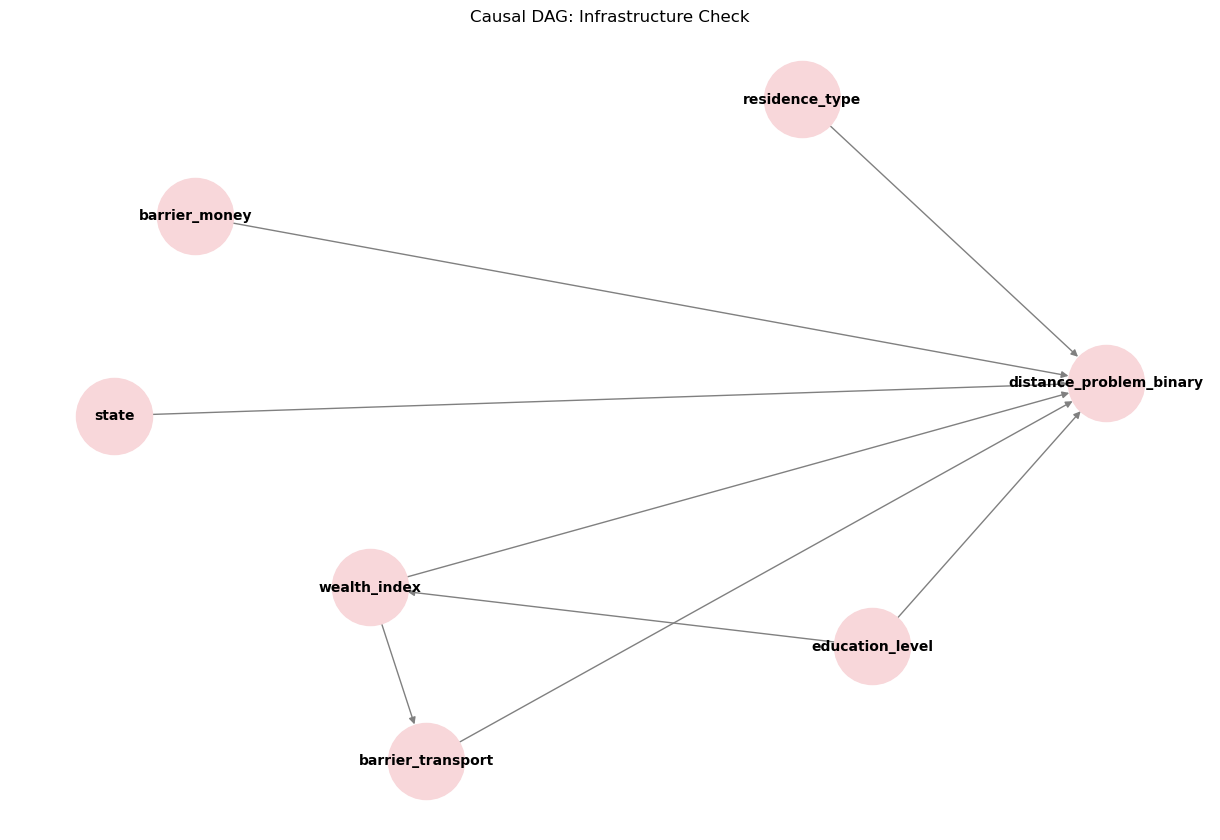

In [12]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import warnings
import logging

# Suppress standard Python and Pandas warnings
warnings.filterwarnings('ignore')

# Silence DoWhy's verbose logging (only show critical errors)
logging.getLogger('dowhy').setLevel(logging.ERROR)

# ==========================================
# 1. DATA PREPARATION & AUDIT
# ==========================================
print("Loading data...")
df = pd.read_csv('india_nfhs5_cleaned.csv')

# Defining our specific nodes for Q9
# Note: barrier_money is a confounder, barrier_transport is a mediator
columns_to_keep = [
    'wealth_index', 'barrier_distance', 'barrier_transport', 
    'residence_type', 'state', 'education_level', 'barrier_money'
]

initial_count = len(df)
df = df.dropna(subset=columns_to_keep).copy()
final_count = len(df)

# Binarize the Outcome: Is distance a problem?
# 1 = Big or Not Big Problem, 0 = No Problem
df['distance_problem_binary'] = np.where(df['barrier_distance'].isin([1, 2]), 1, 0)

# DATA BALANCE & AUDIT PRINT STATEMENTS
print("-" * 30)
print(f"DATA AUDIT REPORT")
print("-" * 30)
print(f"Initial row count: {initial_count}")
print(f"Final row count after dropping NaNs: {final_count}")
print(f"Rows lost: {initial_count - final_count} ({((initial_count - final_count)/initial_count)*100:.2f}%)")

print("\nCHECKING TREATMENT BALANCE (Wealth Index Distribution):")
print(df['wealth_index'].value_counts(normalize=True).sort_index().to_string())

print("\nCHECKING OUTCOME BALANCE (Is Distance a Problem?):")
print(df['distance_problem_binary'].value_counts(normalize=True).to_string())
print("-" * 30)

# Categorical Encoding for non-linear variables
categorical_cols = ['state', 'residence_type', 'barrier_transport', 'barrier_money']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# ==========================================
# 2. STEP 1 & 2: MODEL AND IDENTIFY
# ==========================================
print("\nInitializing DoWhy Model (Infrastructure Check)...")

# DAG Logic: Testing if Wealth affects Distance directly or if it's all State/Residence
causal_graph = """
digraph {
    wealth_index -> distance_problem_binary;
    wealth_index -> barrier_transport;
    barrier_transport -> distance_problem_binary;

    state -> distance_problem_binary;
    residence_type -> distance_problem_binary;
    barrier_money -> distance_problem_binary;

    education_level -> wealth_index;
    education_level -> distance_problem_binary;
}
"""

model = CausalModel(
    data=df,
    treatment='wealth_index',
    outcome='distance_problem_binary',
    graph=causal_graph
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

# ==========================================
# 3. STEP 3: ESTIMATE (INFRASTRUCTURE COMPETITION)
# ==========================================
print("\nEstimating Causal Effects...")

# Total Effect: Does money solve distance overall?
estimate_total = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)

# Direct Effect: Does money solve distance if we freeze transport & structural factors?
formula_direct = (
    "distance_problem_binary ~ wealth_index + barrier_transport + "
    "state + residence_type + education_level + barrier_money"
)
results_direct = smf.ols(formula_direct, data=df).fit()

# Extraction logic for clean printing
total_coef = estimate_total.value
total_coef = total_coef[0] if isinstance(total_coef, (np.ndarray, list)) else total_coef
total_pval = estimate_total.test_stat_significance()['p_value']
total_pval = total_pval[0] if isinstance(total_pval, (np.ndarray, list, tuple)) else total_pval

print("\n=======================================================")
print("INFRASTRUCTURE CHECK: WEALTH vs. DISTANCE LOGISTICS")
print("=======================================================")
print(f"Total Effect of Wealth:  {total_coef:.5f} (p={total_pval:.4f})")
print(f"Direct Effect of Wealth: {results_direct.params['wealth_index']:.5f} (p={results_direct.pvalues['wealth_index']:.4f})")
print("=======================================================\n")

# ==========================================
# 4. STEP 4: REFUTE (FULL ROBUSTNESS SUITE)
# ==========================================
print("Running Full Robustness Suite...")

# Test 1: Random Common Cause (Is there a hidden factor?)
print("\n[Refutation 1/3] Adding a Random Common Cause...")
print(model.refute_estimate(identified_estimand, estimate_total, 
                            method_name="random_common_cause", num_simulations=5))

# Test 2: Placebo Treatment (Does random wealth affect distance? Should be 0)
print("\n[Refutation 2/3] Replacing Wealth with a Placebo...")
print(model.refute_estimate(identified_estimand, estimate_total, 
                            method_name="placebo_treatment_refuter", 
                            placebo_type="permute", num_simulations=5))

# Test 3: Data Subset (Is this result consistent across India?)
print("\n[Refutation 3/3] Running on 80% Data Subset...")
print(model.refute_estimate(identified_estimand, estimate_total, 
                            method_name="data_subset_refuter", 
                            subset_fraction=0.8, num_simulations=5))

# ==========================================
# 5. DAG VISUALIZATION
# ==========================================
nx_graph = model._graph._graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(nx_graph, seed=42)
nx.draw(nx_graph, pos, with_labels=True, node_size=3000, node_color="#f8d7da", font_size=10, font_weight="bold", edge_color="gray")
plt.title("Causal DAG: Infrastructure Check")

## 3. Empowerment Variables


Loading NFHS-5 Dataset...
--------------------------------------------------
AUDIT: Elite Model N = 94288
AUDIT: Inclusive Model N = 676606
--------------------------------------------------

Calculating Causal Estimates (Mechanism Competition)...
PRIMARY RESULTS: THE VANGUARD vs. THE MASSES
Independent Variable      | Elite Coef      | Inclusive Coef 
------------------------------------------------------------
Literacy (Skill)          | 0.00781         | 0.00022        
Education (Degree)        | -0.01118        | -0.00171       
Household Wealth          | 0.00383         | 0.00051        
Financial Agency          | 0.47207         | N/A            
REFUTATION SUITE: MODEL A (ELITE)
[Elite] 1/3: Random Common Cause...
Refute: Add a random common cause
Estimated effect:-0.0006111204247729596
New effect:-0.0006121525302973607
p value:0.11075821865268021

[Elite] 2/3: Placebo Treatment...
Refute: Use a Placebo Treatment
Estimated effect:-0.0006111204247729596
New effect:-0.00054392

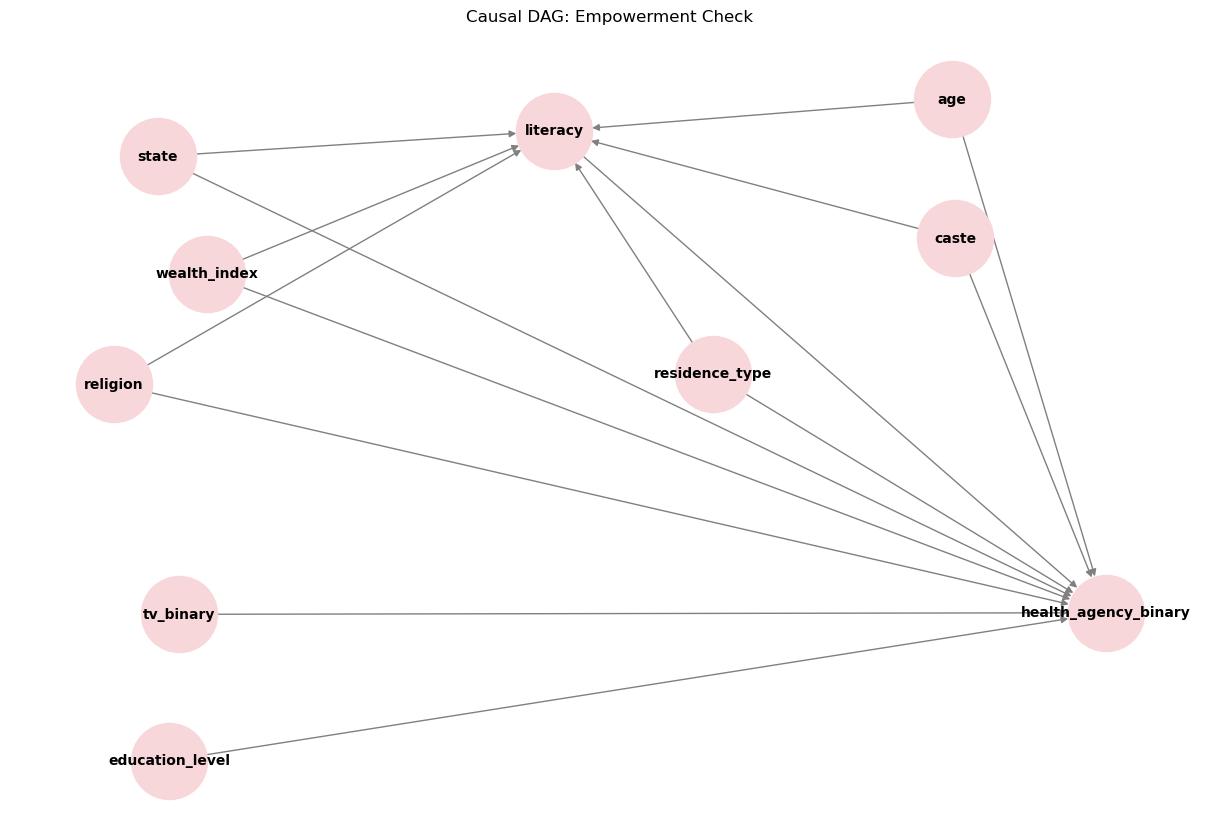

In [26]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import warnings
import logging

# --- SILENCE THE NOISE ---
warnings.filterwarnings('ignore')
logging.getLogger('dowhy').setLevel(logging.ERROR)

# ==========================================
# 1. DATA LOADING & UNIVERSAL PREP
# ==========================================
print("\nLoading NFHS-5 Dataset...")
df_raw = pd.read_csv('india_nfhs5_cleaned.csv')

# Binarize Outcomes
df_raw['health_agency_binary'] = np.where(df_raw['decide_health'].isin([1, 2, 3]), 1, 0)
df_raw['has_financial_agency'] = np.where(df_raw['decide_own_money'].isin([1, 2, 3]), 1, 0)

# <--- MINIMAL CHANGE: MEDIA BINARIZATION --->
df_raw['internet_binary'] = np.where(df_raw['internet_use'] > 0, 1, 0)
df_raw['tv_binary'] = np.where(df_raw['freq_tv'] > 0, 1, 0)

# ==========================================
# 2. DATA AUDIT & FILTERING
# ==========================================
cols_elite = ['health_agency_binary', 'literacy', 'education_level', 'has_financial_agency',
              'wealth_index', 'age', 'state', 'caste', 'religion',
              'internet_binary', 'tv_binary', 'occupation', 'residence_type']
df_elite = df_raw.dropna(subset=cols_elite).copy()

cols_inclusive = ['health_agency_binary', 'literacy', 'education_level', 
                  'wealth_index', 'age', 'state', 'caste', 'religion',
                  'tv_binary', 'residence_type']
df_inclusive = df_raw.dropna(subset=cols_inclusive).copy()

print("-" * 50)
print(f"AUDIT: Elite Model N = {len(df_elite)}")
print(f"AUDIT: Inclusive Model N = {len(df_inclusive)}")
print("-" * 50)

# Categorical Casting
for col in ['state', 'caste', 'religion', 'occupation', 'residence_type']:
    if col in df_elite.columns: df_elite[col] = df_elite[col].astype('category')
    if col in df_inclusive.columns: df_inclusive[col] = df_inclusive[col].astype('category')

# ==========================================
# 3. IMMEDIATE ESTIMATION (The "Answers")
# ==========================================
print("\nCalculating Causal Estimates (Mechanism Competition)...")

# Umbrella Competition: Model A (Elite)
form_elite = "health_agency_binary ~ literacy + education_level + has_financial_agency + wealth_index + age + C(state) + C(caste) + C(religion) + internet_binary + tv_binary + C(occupation) + residence_type"
res_elite = smf.ols(form_elite, data=df_elite).fit()

# Umbrella Competition: Model B (Inclusive)
form_inclusive = "health_agency_binary ~ literacy + education_level + wealth_index + age + C(state) + C(caste) + C(religion) + tv_binary + residence_type"
res_inclusive = smf.ols(form_inclusive, data=df_inclusive).fit()

print("PRIMARY RESULTS: THE VANGUARD vs. THE MASSES")
print(f"{'Independent Variable':<25} | {'Elite Coef':<15} | {'Inclusive Coef':<15}")
print("-" * 60)
print(f"{'Literacy (Skill)':<25} | {res_elite.params['literacy']:<15.5f} | {res_inclusive.params['literacy']:<15.5f}")
print(f"{'Education (Degree)':<25} | {res_elite.params['education_level']:<15.5f} | {res_inclusive.params['education_level']:<15.5f}")
print(f"{'Household Wealth':<25} | {res_elite.params['wealth_index']:<15.5f} | {res_inclusive.params['wealth_index']:<15.5f}")
if 'has_financial_agency' in res_elite.params:
    print(f"{'Financial Agency':<25} | {res_elite.params['has_financial_agency']:<15.5f} | {'N/A':<15}")

# ==========================================
# 4. INITIALIZE DOWHY & RUN REFUTATIONS
# ==========================================

# -- Model A Refutations --
print("="*50)
print("REFUTATION SUITE: MODEL A (ELITE)")
print("="*50)
graph_elite = """
digraph {
    literacy -> health_agency_binary;
    education_level -> health_agency_binary;
    has_financial_agency -> health_agency_binary;
    wealth_index -> health_agency_binary;

    age -> health_agency_binary;
    state -> health_agency_binary;
    caste -> health_agency_binary;
    religion -> health_agency_binary;
    internet_binary -> health_agency_binary;
    tv_binary -> health_agency_binary;
    occupation -> health_agency_binary;
    residence_type -> health_agency_binary;

    age -> literacy;
    state -> literacy;
    caste -> literacy;
    religion -> literacy;
    wealth_index -> literacy;
    residence_type -> literacy;
}
"""
model_a = CausalModel(data=df_elite, treatment='literacy', outcome='health_agency_binary', graph=graph_elite)
id_a = model_a.identify_effect(proceed_when_unidentifiable=True)
est_a = model_a.estimate_effect(id_a, method_name="backdoor.linear_regression")

print("[Elite] 1/3: Random Common Cause...")
print(model_a.refute_estimate(id_a, est_a, method_name="random_common_cause", num_simulations=5))
print("[Elite] 2/3: Placebo Treatment...")
print(model_a.refute_estimate(id_a, est_a, method_name="placebo_treatment_refuter", num_simulations=5))
print("[Elite] 3/3: Data Subset (80%)...")
print(model_a.refute_estimate(id_a, est_a, method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=5))

# -- Model B Refutations --
print("\n" + "="*50)
print("REFUTATION SUITE: MODEL B (INCLUSIVE)")
print("="*50)
graph_inclusive = """
digraph {
    literacy -> health_agency_binary;
    education_level -> health_agency_binary;
    wealth_index -> health_agency_binary;

    age -> health_agency_binary;
    state -> health_agency_binary;
    caste -> health_agency_binary;
    religion -> health_agency_binary;
    tv_binary -> health_agency_binary;
    residence_type -> health_agency_binary;

    age -> literacy;
    state -> literacy;
    caste -> literacy;
    religion -> literacy;
    wealth_index -> literacy;
    residence_type -> literacy;
}
"""
model_b = CausalModel(data=df_inclusive, treatment='literacy', outcome='health_agency_binary', graph=graph_inclusive)
id_b = model_b.identify_effect(proceed_when_unidentifiable=True)
est_b = model_b.estimate_effect(id_b, method_name="backdoor.linear_regression")

print("[Inclusive] 1/3: Random Common Cause...")
print(model_b.refute_estimate(id_b, est_b, method_name="random_common_cause", num_simulations=5))
print("[Inclusive] 2/3: Placebo Treatment...")
print(model_b.refute_estimate(id_b, est_b, method_name="placebo_treatment_refuter", num_simulations=5))
print("[Inclusive] 3/3: Data Subset (80%)...")
print(model_b.refute_estimate(id_b, est_b, method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=5))

# ==========================================
# 5. DAG VISUALIZATION
# ==========================================
nx_graph = model_b._graph._graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(nx_graph, seed=42)
nx.draw(nx_graph, pos, with_labels=True, node_size=3000, node_color="#f8d7da", font_size=10, font_weight="bold", edge_color="gray")
plt.title("Causal DAG: Empowerment Check")
plt.show()

## 4. Effects of different Media types

Loading NFHS-5 Dataset...

Calculating Causal Estimates ...
PRIMARY RESULTS: INTERNET vs. TV (THE UNIVERSAL SOLVER CHECK)
Variable             | Full Pop Coef   | Urban Coef      | Rural Coef     
---------------------------------------------------------------------------
Internet Access      | 0.03797         | 0.04899         | 0.03190        
TV Access            | 0.04303         | 0.04731         | 0.04280        
Wealth Index         | -0.00705        | -0.01492        | -0.00728       
Education Level      | 0.00515         | 0.00665         | 0.00441        

REFUTATION SUITE: INTERNET ACCESS

[Universal Solver] 1/3: Random Common Cause...
Refute: Add a random common cause
Estimated effect:0.03742435306799374
New effect:0.037415894132427255
p value:0.2758811867247587


[Universal Solver] 2/3: Placebo Treatment...
Refute: Use a Placebo Treatment
Estimated effect:0.03742435306799374
New effect:5.2124699933608906e-05
p value:0.49257282716440326


[Universal Solver] 3/3: Data Subse

Text(0.5, 1.0, 'Causal DAG: Information Shocks vs. Elite Badges')

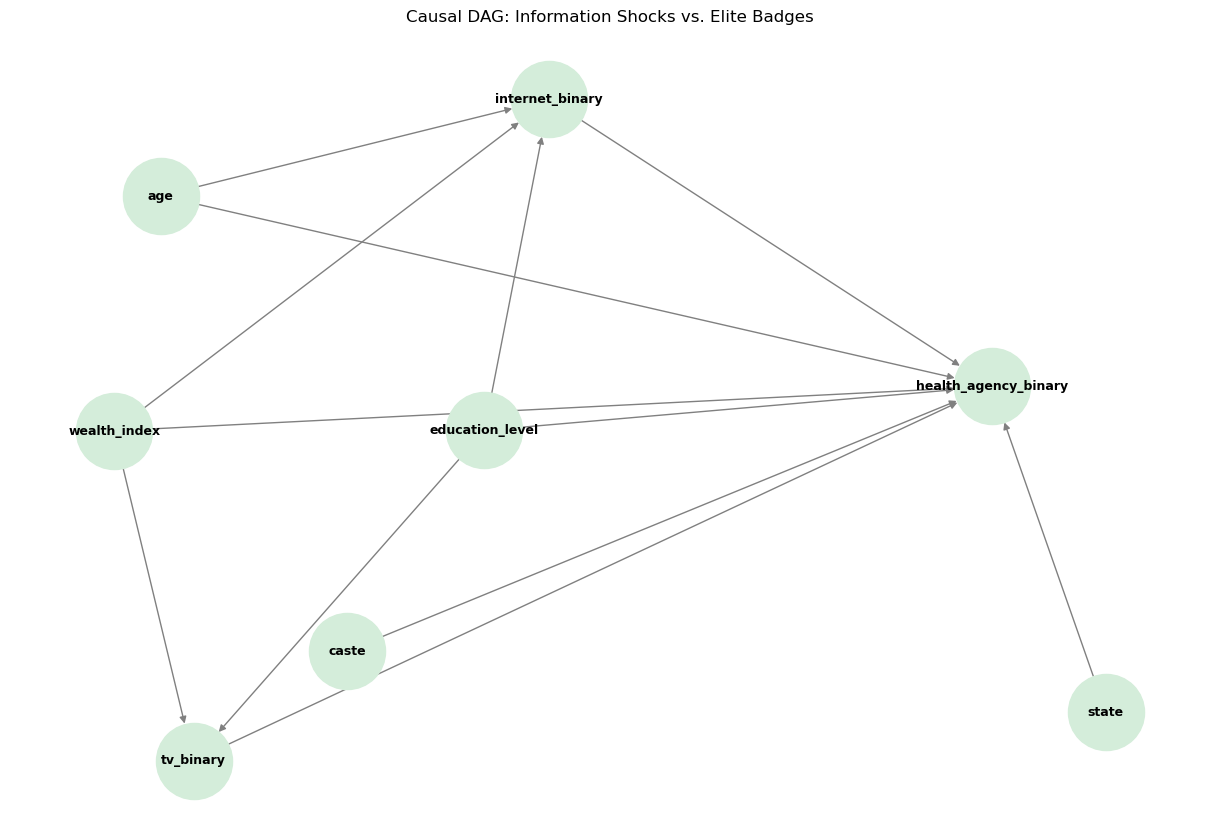

In [22]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from dowhy import CausalModel
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('dowhy').setLevel(logging.ERROR)

print("Loading NFHS-5 Dataset...")
df_raw = pd.read_csv('india_nfhs5_cleaned.csv')

# The "Universal Solver" Columns
cols_info_shock = [
    'decide_health', 'internet_use', 'freq_tv', 
    'wealth_index', 'education_level', 
    'age', 'state', 'caste', 'residence_type'
]

df = df_raw.dropna(subset=cols_info_shock).copy()

# 1. Binarize Outcome
df['health_agency_binary'] = np.where(df['decide_health'].isin([1, 2, 3]), 1, 0)

# 2. PROPER VARIABLE ENCODING (Based on Dictionary)
# Internet: 0 = Never, 1/2/3 = Yes
df['internet_binary'] = np.where(df['internet_use'] > 0, 1, 0)

# TV: 0 = Not at all, 1/2/3 = Yes (watches at least sometimes)
df['tv_binary'] = np.where(df['freq_tv'] > 0, 1, 0)

# Categorical Casting for Structural Controls
for col in ['state', 'caste', 'residence_type']:
    df[col] = df[col].astype('category')

# Split the populations
df_urban = df[df['residence_type'] == 1].copy()
df_rural = df[df['residence_type'] == 2].copy()

# ==========================================
# ESTIMATION: THE CLEANED MEDIA SPLIT
# ==========================================
print("\nCalculating Causal Estimates ...")

# Using the new Binarized variables
formula = (
    "health_agency_binary ~ internet_binary + tv_binary + "
    "wealth_index + education_level + age + C(state) + C(caste)"
)

res_all = smf.ols(formula, data=df).fit()
res_urban = smf.ols(formula, data=df_urban).fit()
res_rural = smf.ols(formula, data=df_rural).fit()

print("PRIMARY RESULTS: INTERNET vs. TV (THE UNIVERSAL SOLVER CHECK)")
print(f"{'Variable':<20} | {'Full Pop Coef':<15} | {'Urban Coef':<15} | {'Rural Coef':<15}")
print("-" * 75)
print(f"{'Internet Access':<20} | {res_all.params['internet_binary']:<15.5f} | {res_urban.params['internet_binary']:<15.5f} | {res_rural.params['internet_binary']:<15.5f}")
print(f"{'TV Access':<20} | {res_all.params['tv_binary']:<15.5f} | {res_urban.params['tv_binary']:<15.5f} | {res_rural.params['tv_binary']:<15.5f}")
print(f"{'Wealth Index':<20} | {res_all.params['wealth_index']:<15.5f} | {res_urban.params['wealth_index']:<15.5f} | {res_rural.params['wealth_index']:<15.5f}")
print(f"{'Education Level':<20} | {res_all.params['education_level']:<15.5f} | {res_urban.params['education_level']:<15.5f} | {res_rural.params['education_level']:<15.5f}")

# ==========================================
# REFUTATION SUITE (FULL POPULATION)
# ==========================================
print("\n" + "="*50)
print("REFUTATION SUITE: INTERNET ACCESS")
print("="*50)

causal_graph = """
digraph {
    internet_binary -> health_agency_binary;
    tv_binary -> health_agency_binary;
    
    wealth_index -> internet_binary; wealth_index -> tv_binary; wealth_index -> health_agency_binary;
    education_level -> internet_binary; education_level -> tv_binary; education_level -> health_agency_binary;
    
    age -> internet_binary; age -> health_agency_binary;
    state -> health_agency_binary;
    caste -> health_agency_binary;
}
"""

model_info = CausalModel(
    data=df,
    treatment='internet_binary',
    outcome='health_agency_binary',
    graph=causal_graph
)

id_info = model_info.identify_effect(proceed_when_unidentifiable=True)
est_info = model_info.estimate_effect(id_info, method_name="backdoor.linear_regression")

print("\n[Universal Solver] 1/3: Random Common Cause...")
print(model_info.refute_estimate(id_info, est_info, method_name="random_common_cause", num_simulations=5))

print("\n[Universal Solver] 2/3: Placebo Treatment...")
print(model_info.refute_estimate(id_info, est_info, method_name="placebo_treatment_refuter", num_simulations=5))

print("\n[Universal Solver] 3/3: Data Subset (80%)...")
print(model_info.refute_estimate(id_info, est_info, method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=5))

# ==========================================
# VISUALIZATION
# ==========================================
print("\nGenerating Visualization...")
nx_graph = model_info._graph._graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(nx_graph, seed=42)
nx.draw(nx_graph, pos, with_labels=True, node_size=3000, node_color="#d4edda", font_size=9, font_weight="bold", edge_color="gray", arrows=True)
plt.title("Causal DAG: Information Shocks vs. Elite Badges")

## 5. Caste-based Barriers and Solutions

Loading NFHS-5 Dataset...

AUDIT: THE SYSTEMIC FRICTION DATASET
Initial row count: 724115
Final row count:   101775 (Retention: 14.06%)
--------------------------------------------------
Urban Sub-population (N): 25243
Rural Sub-population (N): 76532
Reserved Caste Balance:   80.61%

Calculating Causal Estimates (Systemic Bias, Insurance, & Urban Drop)...
RESULTS: POOLED SYSTEMIC BIAS & INSURANCE PARADOX
Path Examined (Pooled)                   | Coefficient     | P-Value        
---------------------------------------------------------------------------
Q6: Caste -> No Provider Barrier        | 0.01448         | 0.0005         
Q7a: Caste -> Has Govt Insurance        | 0.01442         | 0.0000         
Q7b: Govt Insurance -> Financial Barrier| -0.00915        | 0.0159         
TEST C: THE URBAN EQUALIZER (Does the Caste Penalty Drop?)
Barrier Type              | Rural Caste Penalty  | Urban Caste Penalty 
---------------------------------------------------------------------------
Phys

Text(0.5, 1.0, 'Causal DAG: Systemic Friction & The Insurance Paradox')

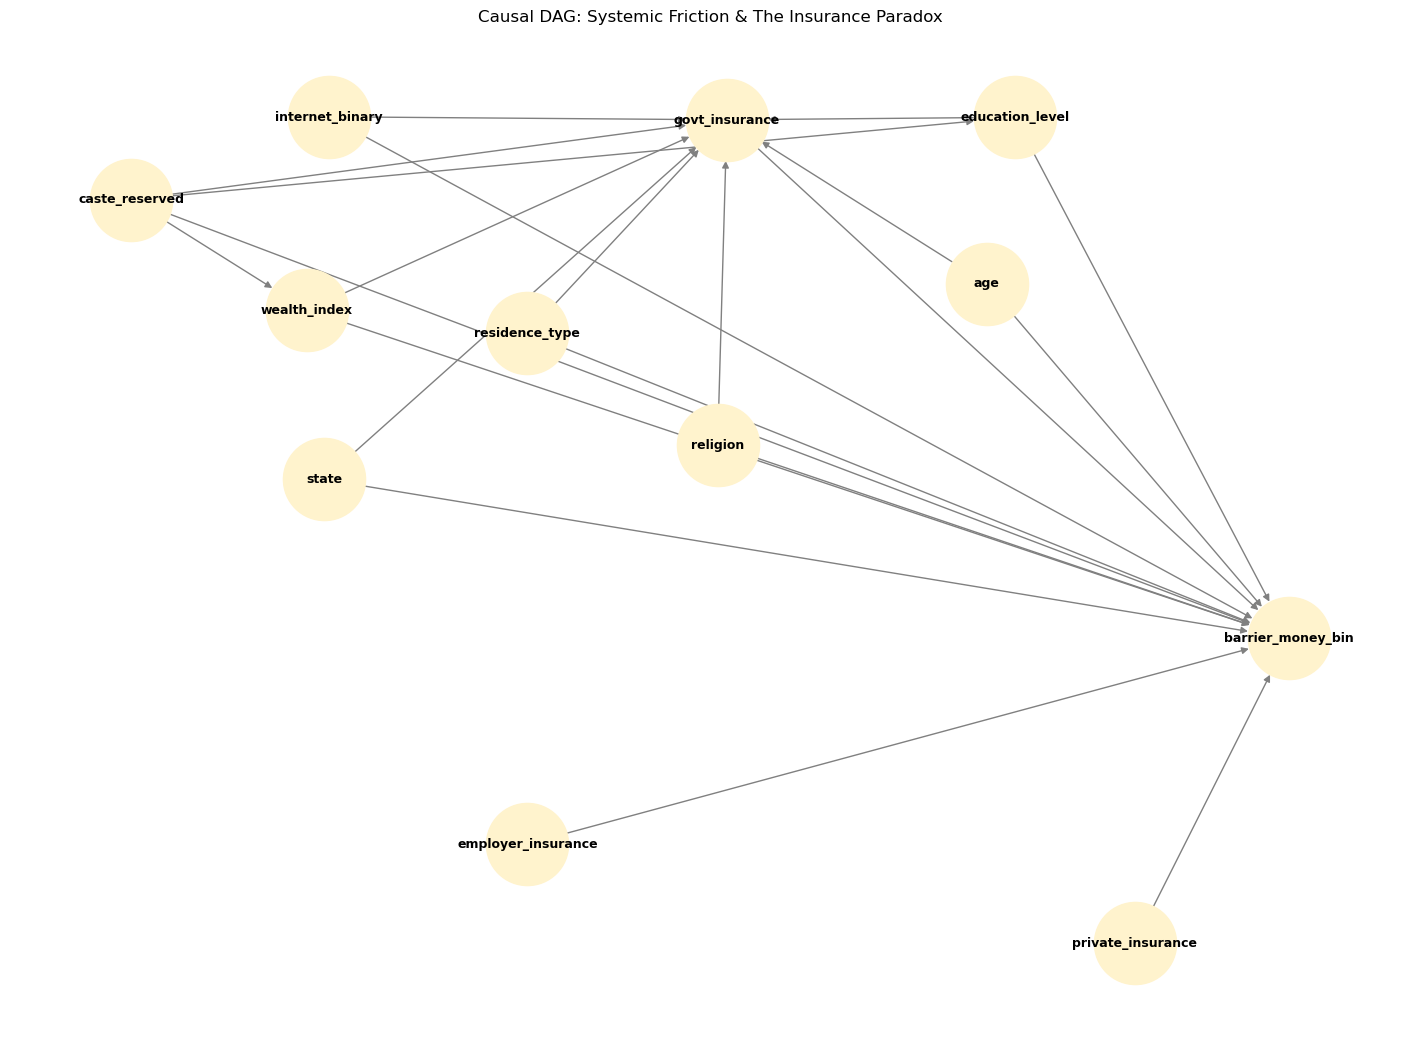

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import warnings
import logging

# --- SILENCE THE NOISE ---
warnings.filterwarnings('ignore')
logging.getLogger('dowhy').setLevel(logging.ERROR)

# ==========================================
# 1. DATA LOADING & PROPER ENCODING
# ==========================================
print("Loading NFHS-5 Dataset...")
df_raw = pd.read_csv('india_nfhs5_cleaned.csv')

# The Systemic Friction Columns
cols_systemic = [
    'caste', 'barrier_no_provider', 'barrier_money', 'govt_insurance',
    'private_insurance', 'employer_insurance',
    'wealth_index', 'education_level', 'internet_use',
    'state', 'residence_type', 'religion', 'age'
]

initial_count = len(df_raw)
df = df_raw.dropna(subset=cols_systemic).copy()
final_count = len(df)

# --- STRICT VARIABLE ENCODING ---
# Caste: 1=SC, 2=ST, 3=OBC -> Reserved (1), 4=None -> Unreserved (0)
df['caste_reserved'] = np.where(df['caste'].isin([1, 2, 3]), 1, 0)

# Outcomes: 1=Big problem -> Barrier Exists (1), 0=No problem, 2=Not a big problem -> No Barrier (0)
df['barrier_provider_bin'] = np.where(df['barrier_no_provider'] == 1, 1, 0)
df['barrier_money_bin'] = np.where(df['barrier_money'] == 1, 1, 0)

# Information Backdoor
df['internet_binary'] = np.where(df['internet_use'] > 0, 1, 0)

# Categorical Casting for Fixed Effects
for col in ['state', 'residence_type', 'religion']:
    df[col] = df[col].astype('category')

# ==========================================
# 2. DATA AUDIT
# ==========================================
print("\n" + "="*50)
print("AUDIT: THE SYSTEMIC FRICTION DATASET")
print("="*50)
print(f"Initial row count: {initial_count}")
print(f"Final row count:   {final_count} (Retention: {(final_count/initial_count)*100:.2f}%)")
print("=" * 50)

# ==========================================
# 3. ESTIMATION: THE OLS COMPETITIONS
# ==========================================
print("\nCalculating Causal Estimates (Systemic Bias, Insurance, & Urban Drop)...")

# Base controls (Note: residence_type is omitted here so we can reuse the string for the split datasets safely)
base_controls = "wealth_index + education_level + internet_binary + age + C(religion) + C(state)"

# -- POOLED MODELS (Q6 & Q7) --
form_q6_pooled = f"barrier_provider_bin ~ caste_reserved + C(residence_type) + {base_controls}"
res_q6_pooled = smf.ols(form_q6_pooled, data=df).fit()

form_q7a_pooled = f"govt_insurance ~ caste_reserved + C(residence_type) + {base_controls}"
res_q7a_pooled = smf.ols(form_q7a_pooled, data=df).fit()

form_q7b_pooled = f"barrier_money_bin ~ govt_insurance + caste_reserved + private_insurance + employer_insurance + C(residence_type) + {base_controls}"
res_q7b_pooled = smf.ols(form_q7b_pooled, data=df).fit()


print("RESULTS: POOLED SYSTEMIC BIAS & INSURANCE PARADOX")
print(f"{'Path Examined (Pooled)':<40} | {'Coefficient':<15} | {'P-Value':<15}")
print("-" * 75)
print(f"Q6: Caste -> No Provider Barrier        | {res_q6_pooled.params['caste_reserved']:<15.5f} | {res_q6_pooled.pvalues['caste_reserved']:<15.4f}")
print(f"Q7a: Caste -> Has Govt Insurance        | {res_q7a_pooled.params['caste_reserved']:<15.5f} | {res_q7a_pooled.pvalues['caste_reserved']:<15.4f}")
print(f"Q7b: Govt Insurance -> Financial Barrier| {res_q7b_pooled.params['govt_insurance']:<15.5f} | {res_q7b_pooled.pvalues['govt_insurance']:<15.4f}")

# ==========================================
# 4. DOWHY CAUSAL MODEL & REFUTATION
# ==========================================
print("\n" + "="*50)
print("REFUTATION SUITE: GOVT INSURANCE EFFECTIVENESS (POOLED)")
print("="*50)

# Full DAG checking if Govt Insurance solves the Money Barrier
causal_graph = """
digraph {
    govt_insurance -> barrier_money_bin;
    caste_reserved -> govt_insurance;
    caste_reserved -> barrier_money_bin;
    
    wealth_index -> govt_insurance; wealth_index -> barrier_money_bin;
    education_level -> govt_insurance; education_level -> barrier_money_bin;
    internet_binary -> govt_insurance; internet_binary -> barrier_money_bin;
    age -> govt_insurance; age -> barrier_money_bin;
    state -> govt_insurance; state -> barrier_money_bin;
    residence_type -> govt_insurance; residence_type -> barrier_money_bin;
    religion -> govt_insurance; religion -> barrier_money_bin;
    
    private_insurance -> barrier_money_bin;
    employer_insurance -> barrier_money_bin;
    
    caste_reserved -> wealth_index;
    caste_reserved -> education_level;
}
"""

model_insurance = CausalModel(
    data=df,
    treatment='govt_insurance',
    outcome='barrier_money_bin',
    graph=causal_graph
)

id_insurance = model_insurance.identify_effect(proceed_when_unidentifiable=True)
est_insurance = model_insurance.estimate_effect(id_insurance, method_name="backdoor.linear_regression")

print("\n[Insurance Shield] 1/3: Random Common Cause...")
print(model_insurance.refute_estimate(id_insurance, est_insurance, method_name="random_common_cause", num_simulations=5))

print("\n[Insurance Shield] 2/3: Placebo Treatment...")
print(model_insurance.refute_estimate(id_insurance, est_insurance, method_name="placebo_treatment_refuter", num_simulations=5))

print("\n[Insurance Shield] 3/3: Data Subset (80%)...")
print(model_insurance.refute_estimate(id_insurance, est_insurance, method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=5))

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("\nGenerating Visualization...")
nx_graph = model_insurance._graph._graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(nx_graph, seed=42)
nx.draw(nx_graph, pos, with_labels=True, node_size=3500, node_color="#fff3cd", font_size=9, font_weight="bold", edge_color="gray", arrows=True)
plt.title("Causal DAG: Systemic Friction & The Insurance Paradox")

## Final List of Conclusions

 1. Money vs. Infrastructure: While wealth seems helpful at first, its power to solve distance problems drops by 93% once you account for where a woman lives. For women in the same area, having more money only reduces the "distance barrier" by a tiny 0.28%, proving that hospitals are a physical problem that money cannot buy its way out of.

 2. Financial Empowerment: Having a direct say in her own money increases a woman’s healthcare agency by 47.2%. For policy makers, this implies that having money as a household is less useful than women themselves having the money (preferably earning the money themselves too). This ensures she has the power to spend it.

3.  Media vs. Traditional Schooling: For the general population, the ability to read increases power by only 0.02%, and formal education adds only 0.5%. However, TV access (4.3% boost) and Internet access (3.8% boost) are much more effective at breaking patriarchal norms.

4.  The Insurance Failure: Having government insurance reduces financial barriers by less than 1% (specifically 0.9%). This proves the system fails at the point of care, likely because it does not cover the "hidden" costs of medicines and basic checkups.